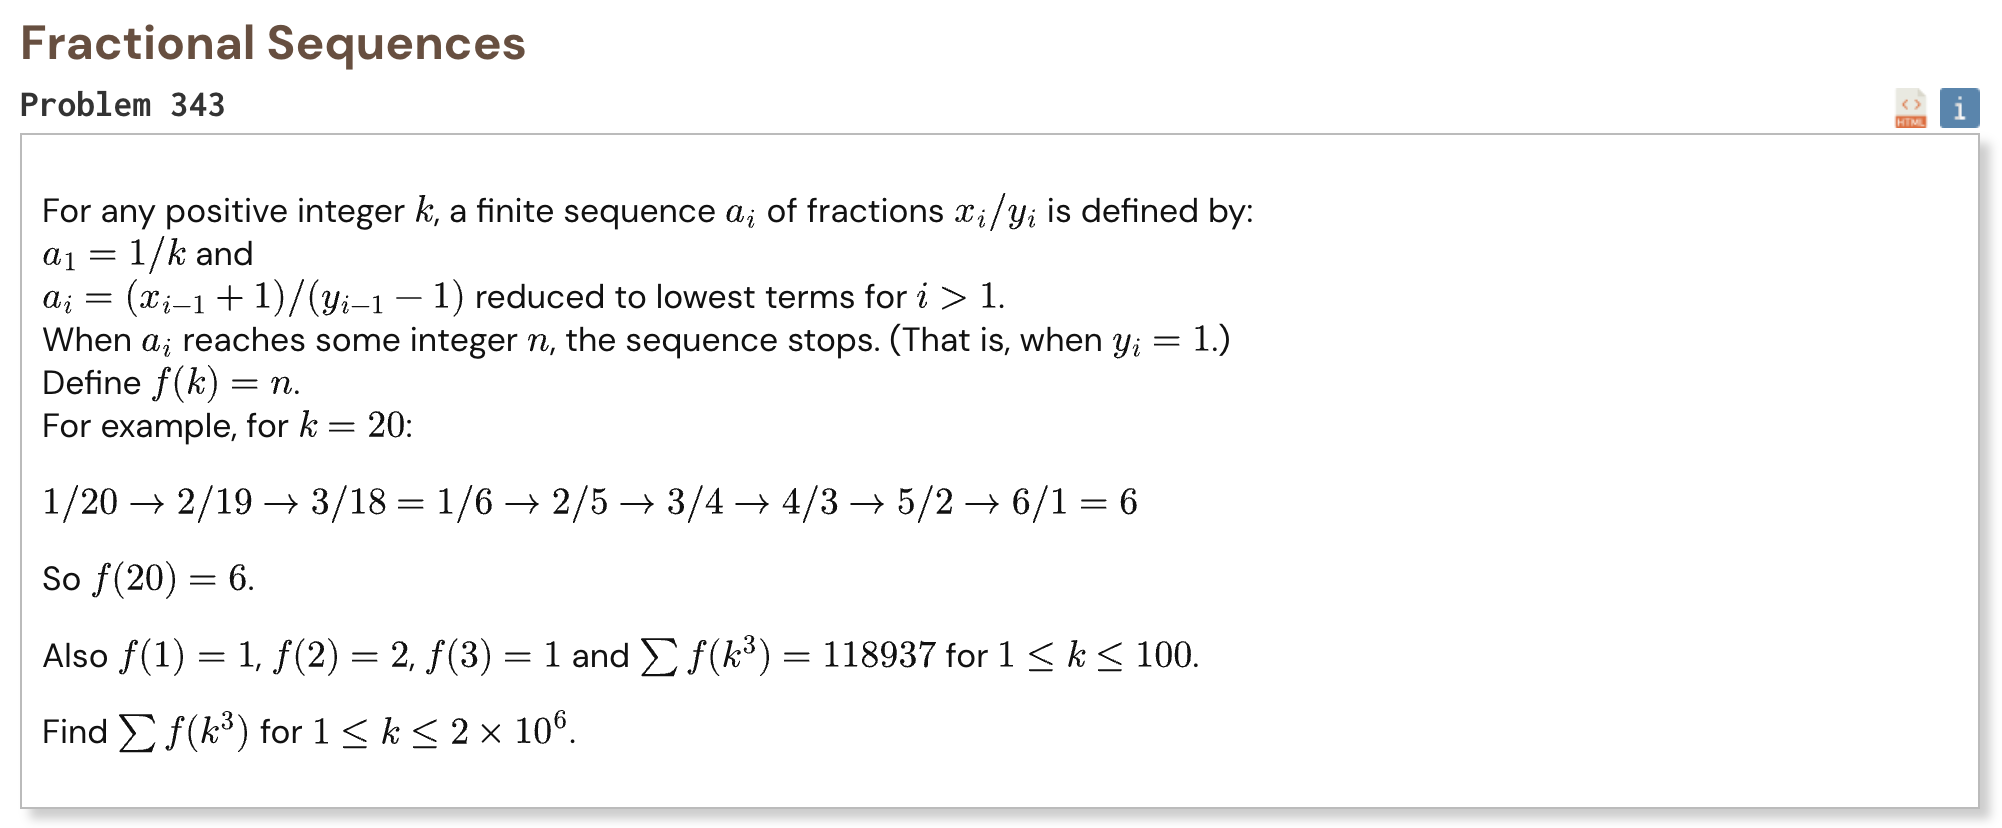

## Initial approach

* do not simulate the fraction sequence directly
* the final value depends on the largest prime factor behind the sequence
* split the expression into an easy linear part and a harder quadratic part
* factor the linear part with a smallest-prime-factor sieve
* factor the quadratic part by marking only primes that can divide it
* keep the largest prime factor found for every k
* sum one less than that largest prime factor

In [1]:
import math

def prime_sieve_and_spf(limit):
    spf = list(range(limit + 1))
    primes = []

    for i in range(2, limit + 1):
        if spf[i] == i:
            primes.append(i)

        for p in primes:
            v = i * p

            if v > limit:
                break

            spf[v] = p

            if p == spf[i]:
                break

    return primes, spf

def tonelli_shanks(n, p):
    n %= p

    if n == 0:
        return 0

    if p == 2:
        return n

    if pow(n, (p - 1) // 2, p) != 1:
        return None

    if p % 4 == 3:
        return pow(n, (p + 1) // 4, p)

    q = p - 1
    s = 0

    while q % 2 == 0:
        s += 1
        q //= 2

    z = 2

    while pow(z, (p - 1) // 2, p) != p - 1:
        z += 1

    m = s
    c = pow(z, q, p)
    t = pow(n, q, p)
    r = pow(n, (q + 1) // 2, p)

    while t != 1:
        i = 1
        temp = pow(t, 2, p)

        while temp != 1:
            temp = pow(temp, 2, p)
            i += 1

        b = pow(c, 1 << (m - i - 1), p)
        m = i
        c = b * b % p
        t = t * c % p
        r = r * b % p

    return r

def factor_linear_parts(limit, spf, largest):
    for k in range(1, limit + 1):
        x = k + 1

        while x > 1:
            p = spf[x]
            largest[k] = max(largest[k], p)

            while x % p == 0:
                x //= p

def factor_quadratic_parts(limit, primes, largest):
    values = [0] * (limit + 1)

    for k in range(1, limit + 1):
        values[k] = k * k - k + 1

    for p in primes:
        if p == 2:
            continue

        if p == 3:
            roots = [2]
        elif p % 6 == 1:
            root = tonelli_shanks(p - 3, p)
            inv2 = (p + 1) // 2
            roots = [(1 + root) * inv2 % p, (1 - root) * inv2 % p]
        else:
            continue

        for root in roots:
            if root == 0:
                start = p
            else:
                start = root

            for k in range(start, limit + 1, p):
                if values[k] % p == 0:
                    largest[k] = max(largest[k], p)

                    while values[k] % p == 0:
                        values[k] //= p

    for k in range(1, limit + 1):
        if values[k] > 1:
            largest[k] = max(largest[k], values[k])

def solve(limit):
    primes, spf = prime_sieve_and_spf(limit + 1)
    largest = [1] * (limit + 1)

    factor_linear_parts(limit, spf, largest)
    factor_quadratic_parts(limit, primes, largest)

    total = 0

    for k in range(1, limit + 1):
        total += largest[k] - 1

    return total

In [2]:
%%time
result = solve(2_000_000)
print("Result:", result)

Result: 269533451410884183
CPU times: user 6.57 s, sys: 52.9 ms, total: 6.63 s
Wall time: 6.63 s
